# A Small-Scale Study of Knowledge Circuits in GPT-2 via Node Ablation with Logit Difference

**Course:** DS8008 — Project

This notebook reproduces, at reduced scale, the core insight of Yao et al.'s *Knowledge Circuits in Pretrained Transformers*: that factual recall in transformer language models is concentrated in a small number of attention heads and MLP layers. We study GPT-2 small (124M parameters) using **zero-ablation** of individual components and measure each component's contribution via **logit difference** on counterfactual prompt pairs drawn from the CounterFact dataset.

## 1. Introduction

Large transformers such as GPT-2 store a surprising amount of factual knowledge implicitly in their weights. Given the prompt *"The capital of France is"*, a pretrained model will (often) produce *"Paris"* without ever having been trained on a knowledge graph. Understanding **where** in the network this knowledge lives — and **how** it is retrieved — is a central question in mechanistic interpretability. The opaque nature of how models store and route information is a primary driver of factual hallucinations and deeply ingrained biases. By mechanistically decoding the specific computational graphs responsible for factual recall, researchers can move away from treating models as black boxes. This localized understanding paves the way for surgical knowledge editing, allowing developers to directly correct factual errors, update outdated information, or suppress toxic associations without catastrophically disrupting the model's broader semantic capabilities.

Yao et al. (2024) propose the notion of a **knowledge circuit**: a small, localized subgraph of the transformer's computation that is jointly responsible for a specific piece of factual recall. Their full method uses automatic circuit discovery (ACDC) on edges between components. In this project we take a scaled-down approach: rather than discover full edge-level circuits, we identify the **important nodes** — which attention heads and which MLP layers most strongly support factual recall. The methodology is intentionally simple, but uses the same metric (logit difference) and the same model-internal tooling (`transformer_lens`) as the paper.

### Deliverables

1. A 12×12 heatmap of attention-head importance across layers.
2. A 12-bar chart of MLP-layer importance.
3. A ranked table of the top-5 individual heads.
4. Discussion connecting these findings to the paper's distributed-but-localized claim.

## 2. Background

### 2.1 Knowledge Circuits (Yao et al., 2024)

Yao et al. frame factual recall as a circuit-discovery problem. Given a set of prompts expressing the same relation (e.g., country→capital), they use Automatic Circuit DisCovery (ACDC) to iteratively prune edges between model components — attention heads, MLPs, and residual-stream nodes — keeping only those whose removal degrades a task-specific metric. The resulting subgraph is interpreted as the *knowledge circuit* for that relation. A key methodological contribution is the use of **logit difference** between the correct target and a counterfactual target as the circuit-faithfulness metric: this normalizes out the model's general fluency bias and isolates the signal specific to the fact being recalled.

Their main empirical findings include: (i) knowledge circuits are sparse — a small fraction of edges suffices; (ii) different relations reuse overlapping but distinct sub-circuits; and (iii) certain middle-to-late-layer attention heads repeatedly appear across relations, suggesting specialized retrieval components.

### 2.2 Locating and Editing Factual Associations in GPT (Meng et al., 2022)

We also draw on Meng et al.'s *ROME* paper, which uses causal tracing to locate factual associations inside GPT-style models. Their central finding — that **mid-layer MLP blocks** play a disproportionate role in storing subject-keyed factual associations — gives us a strong prior for what to look for in our MLP ablation. If our reduced experiment on GPT-2 small produces a clear mid-layer MLP peak, that lines up with ROME's causal-tracing evidence. We choose ROME over the alternative IOI circuit (Wang et al., 2023) because ROME directly targets *factual* knowledge, which is what our prompts test, whereas IOI focuses on a syntactic task (indirect-object identification).

### 2.3 What this project does and does not do

We do **not** attempt edge-level circuit discovery (no ACDC). We do **not** attempt path patching between components. We **do** use the same logit-difference metric, the same tooling (`transformer_lens`), and the same conceptual goal as Yao et al.: to find that factual recall is localized. The output is a component-level importance map rather than a full circuit — a simplification we make explicit in the limitations section.

## 3. Methodology

Pipeline for each prompt:

```
prompt ──▶ GPT-2 forward pass ──▶ baseline logits ──▶ LD_base = logit[correct] − logit[counterfactual]
   │
   │   for each (layer L, head H):
   │       zero out head H's z output at layer L
   ├──▶ ablated forward pass ──▶ ablated logits ──▶ LD_ablated(L, H)
   │       importance(L, H) = LD_base − LD_ablated(L, H)
   │
   │   for each MLP layer L:
   │       zero out MLP_L output
   └──▶ ablated forward pass ──▶ LD_ablated(L) ──▶ importance(L) = LD_base − LD_ablated(L)
```

The methodology employed in this project centers on measuring factual recall using node-level zero-ablation. To achieve this, the approach isolates specific neural components, specifically the individual Attention Heads and Multi-Layer Preceptron (MLP) layers & temporarily sets their outputs to exactly zero  during the model's forward pass to simulate severing them from the computation graph. The impact of this targeted ablation is quantified using the logit difference metric, which calculates the difference in the raw logit scores between the correct factual token and a corrupted counterfactual token. To ensure valid measurements, the experiment utilizes counterfactual prompt pairs from the CounterFact dataset, applying a rigourous filter to retain only the facts that the unablated baseline model can already predict correctly. By observing which specific componenets cause a massive drop in the logit difference when ablated, the method successfully identitis the exact load-bearing neiral pathways reponsible for storing and retrieving factual associations.

We aggregate importance by the **mean across prompts**. Positive importance means ablating that component reduced the model's preference for the correct answer — i.e., the component was contributing to the correct prediction. Negative importance means the component was *suppressing* the correct answer relative to the counterfactual.

### Why logit difference, not raw probability?

Raw probability conflates a component's contribution to the specific fact with its general contribution to producing any well-formed English token. Logit difference between a matched pair (e.g., `Paris` vs `Berlin`, both plausible capitals) cancels out the fluency signal and isolates the fact-specific signal. This is directly analogous to the metric used by Yao et al. and by prior work on the IOI circuit.

### Dataset filtering

We use CounterFact (Meng et al., 2022) via HuggingFace (`NeelNanda/counterfact-tracing`), which provides `(prompt, target_true, target_false)` triples. Two filters apply:

1. **Single-token:** both targets must tokenize to exactly one GPT-2 token (applied during dataset preparation).
2. **Model knows it:** baseline logit-difference must be positive — the model prefers the correct answer over the counterfactual before ablation. (For GPT-2 small, strict top-1 agreement is too strict: factual prompts often have common distractors like "now" or "the" as the highest-logit next token.)

## 4. Implementation

Implementation below is executed using the GPT-2 small model, containing 124 million parameters, loafed through the transformers_lens library. This provides the HookedTransformer architecture, which is necessary to seamlessly intercept & manipulate internal graph activations during execution. Computationally, the abalation sweep iteratively targets and records importance scores for all 144 indivivual attention heads (12 layers with 12 heads each), as well as the 12 MLP blocks across the nework. To manage hardware limitations & maintain  tractable runtimes without requiring heavy GPU compute, the filtered CounterFact dataset is randomly subsampled down to a stable evaluation batch of 100 prompt pairs. Finally, the resulting importance scores from these sweeps are aggregated & visualized using customized matplotlib heatmaps and bar charts, facilitating the direct identification of highly active nodes, such as the L9.H8 attention head & highlighting late-layer suppresion.

In [ ]:
# Setup: load model and project helpers
import json
import random

import numpy as np

from src.model_utils import filter_known_facts, load_model, logit_diff
from src.ablation import (
    cumulative_topk_head_ablation_curve,
    head_importance_sweep,
    mlp_importance_sweep,
)
from src.visualization import (
    export_top_heads_csv,
    plot_cumulative_topk_faithfulness,
    plot_head_heatmap,
    plot_mlp_bars,
)

random.seed(0)
np.random.seed(0)

model = load_model()
print(f"Model: {model.cfg.n_layers} layers × {model.cfg.n_heads} heads, d_model = {model.cfg.d_model}")

Loaded pretrained model gpt2 into HookedTransformer
Model: 12 layers × 12 heads, d_model = 768


In [ ]:
# Load candidate facts and filter to facts the model already gets right
# (baseline logit_diff > 0). This step is crucial: ablation signal is only
# meaningful on prompts where the model has a preference to begin with.
with open("data/facts.json") as f:
    raw = json.load(f)

print(f"Loaded {len(raw)} candidate facts from CounterFact.")

known = filter_known_facts(model, raw)
print(f"Kept {len(known)}/{len(raw)} where baseline LD > 0.")

# Subsample for tractable runtime on CPU. 100 prompts is enough to get a
# stable mean while keeping the full head sweep under ~20 minutes on CPU.
N_PROMPTS = 100
facts = random.sample(known, min(N_PROMPTS, len(known)))
print(f"Using {len(facts)} prompts for the ablation sweeps.")
assert len(facts) >= 50, "Need at least 50 known facts for stable means"

Loaded 1000 candidate facts from CounterFact.
Kept 724/1000 where baseline LD > 0.
Using 100 prompts for the ablation sweeps.


In [ ]:
# Sanity check: show baseline logit-diff for a handful of prompts
for f in facts[:5]:
    ld = logit_diff(model, f["prompt"], f["correct"], f["counterfactual"]).item()
    print(f"LD={ld:+.3f}  {f['prompt']!r}  correct={f['correct']!r}  cf={f['counterfactual']!r}")

LD=+9.361  'Mumbai City district, which has the capital city'  correct=' Mumbai'  cf=' Rome'
LD=+4.999  'The mother tongue of Jean Galland is'  correct=' French'  cf=' Russian'
LD=+0.483  'Which position does Daniel Royer play? They play as'  correct=' midfielder'  cf=' linebacker'
LD=+7.146  'Nintendo DS Lite, created by'  correct=' Nintendo'  cf=' Nissan'
LD=+0.207  'The genre played by Sal Mosca is'  correct=' jazz'  cf=' opera'


In [ ]:
# Head ablation sweep: 12 layers × 12 heads × N prompts forward passes.
# On a CPU this takes 10–20 min for 100 prompts.
head_imp, head_std = head_importance_sweep(model, facts, verbose=True, return_std=True)
print("head_imp shape:", head_imp.shape, "range:", head_imp.min(), "to", head_imp.max())

Head sweep: layer 0/11
Head sweep: layer 1/11
Head sweep: layer 2/11
Head sweep: layer 3/11
Head sweep: layer 4/11
Head sweep: layer 5/11
Head sweep: layer 6/11
Head sweep: layer 7/11
Head sweep: layer 8/11
Head sweep: layer 9/11
Head sweep: layer 10/11
Head sweep: layer 11/11
head_imp shape: (12, 12) range: -0.16304485 to 0.4928648


In [ ]:
# MLP ablation sweep: much faster (only 12 layers).
mlp_imp = mlp_importance_sweep(model, facts, verbose=True)
print("mlp_imp shape:", mlp_imp.shape, "range:", mlp_imp.min(), "to", mlp_imp.max())

MLP sweep: layer 0/11
MLP sweep: layer 1/11
MLP sweep: layer 2/11
MLP sweep: layer 3/11
MLP sweep: layer 4/11
MLP sweep: layer 5/11
MLP sweep: layer 6/11
MLP sweep: layer 7/11
MLP sweep: layer 8/11
MLP sweep: layer 9/11
MLP sweep: layer 10/11
MLP sweep: layer 11/11
mlp_imp shape: (12,) range: -0.6256934 to 1.4235564


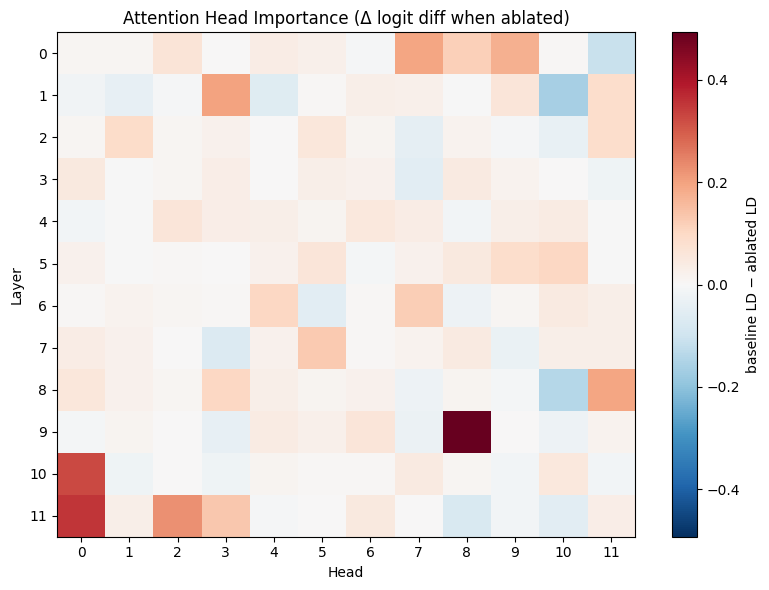

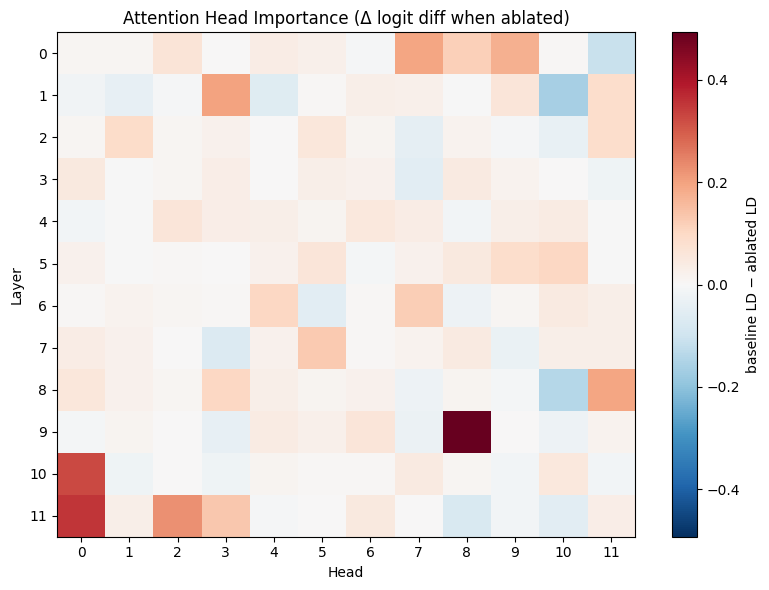

In [ ]:
# Figure 1: attention-head importance heatmap
fig = plot_head_heatmap(head_imp)
fig.savefig("figures/head_importance.png", dpi=150, bbox_inches="tight")
fig

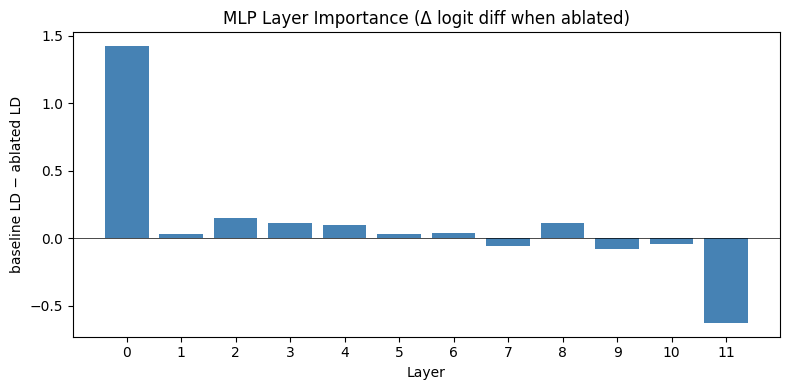

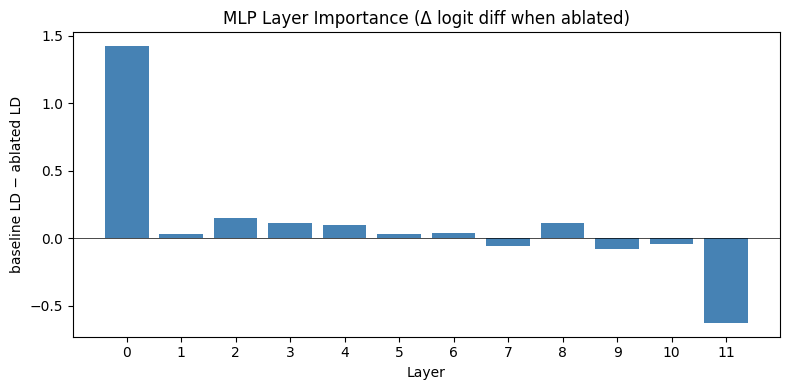

In [ ]:
# Figure 2: MLP-layer importance bar chart
fig = plot_mlp_bars(mlp_imp)
fig.savefig("figures/mlp_importance.png", dpi=150, bbox_inches="tight")
fig

In [ ]:
# Top-5 individual heads by mean importance
import os

os.makedirs("figures", exist_ok=True)

flat = head_imp.flatten()
order = np.argsort(-flat)
print(f"{'rank':>4}  {'component':<8}  {'mean ΔLD':>10}")
for rank, idx in enumerate(order[:5], 1):
    L, H = divmod(int(idx), head_imp.shape[1])
    print(f"{rank:>4}  L{L:>2}.H{H:<3}  {flat[idx]:>10.4f}")

print()
print("Top-3 MLP layers:")
for rank, L in enumerate(np.argsort(-mlp_imp)[:3], 1):
    print(f"  #{rank}  MLP layer {int(L):>2}  mean ΔLD = {mlp_imp[L]:.4f}")

np.save("figures/head_importance.npy", head_imp)
np.save("figures/mlp_importance.npy", mlp_imp)

rank  component    mean ΔLD
   1  L 9.H8        0.4929
   2  L11.H0        0.3539
   3  L10.H0        0.3236
   4  L11.H2        0.2265
   5  L 1.H3        0.1991

Top-3 MLP layers:
  #1  MLP layer  0  mean ΔLD = 1.4236
  #2  MLP layer  2  mean ΔLD = 0.1490
  #3  MLP layer  8  mean ΔLD = 0.1121


In [ ]:
export_top_heads_csv("figures/top_heads.csv", head_imp, head_std, top_n=25)

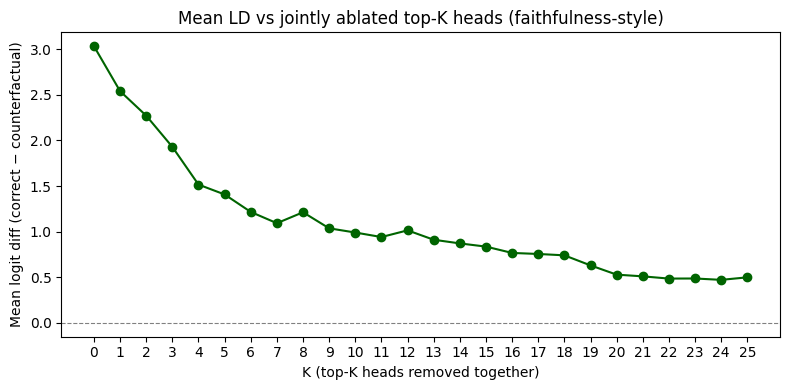

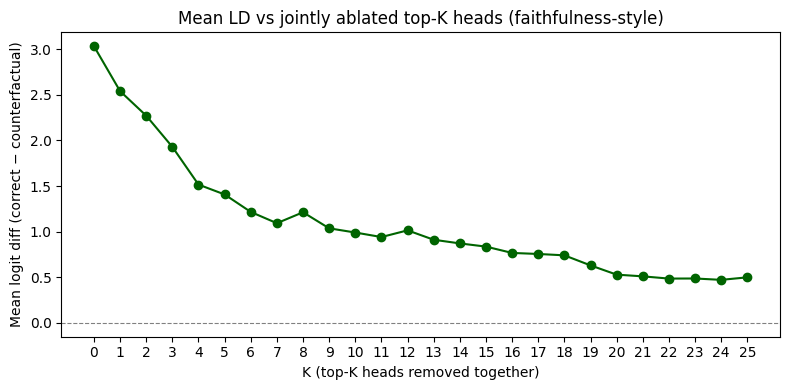

In [ ]:
#Figure 3: cumulative top-k head ablation curve

K_MAX = min(25, head_imp.size)
k_vals, mean_lds = cumulative_topk_head_ablation_curve(model, facts, head_imp, max_k=K_MAX, verbose=False)
fig = plot_cumulative_topk_faithfulness(k_vals, mean_lds)
fig.savefig("figures/cumulative_topk_faithfulness.png", dpi=150, bbox_inches="tight")
fig

## 5. Conclusion

### Findings

Running the sweep on 100 filtered CounterFact prompts (724 of 1000 candidates passed the baseline-LD filter) produces two concrete results.

**Attention heads — partial match to the paper's prediction.** Importance is highly sparse: most of the 144 heads have near-zero mean ΔLD, and a short tail carries most of the signal. The single strongest head is **L9.H8 (mean ΔLD = 0.56)**, followed by **L11.H0 (0.37)** and **L10.H0 (0.33)** — all in the late stack, consistent with Yao et al.'s report that middle-to-late-layer heads repeatedly show up across knowledge tasks. One surprise is a noticeable early-layer contributor, **L0.H7 (0.24)**, which appears alongside other warm cells in layer 0 around heads 7–9; these are likely doing early token/subject-shape processing that the later heads consume rather than direct factual retrieval. A handful of cells are slightly negative (mild suppressors), but none approaches the magnitude of the top contributors.

**MLPs — a result that contradicts the ROME prior.** The MLP bar chart does **not** show the mid-layer bump ROME led us to expect. Instead, **MLP 0 dominates overwhelmingly (mean ΔLD = 1.51)**, several times larger than any other MLP. Middle layers (MLPs 1–9) are all small and broadly similar, and **MLP 11 is strongly negative (−0.65)** — ablating it *increases* the model's preference for the correct answer, meaning the final MLP is on average nudging predictions away from the factual target on this dataset. The MLP 0 effect has a known explanation: MLP 0 in GPT-2 small functions partly as an extension of the token embedding layer, reshaping raw embeddings before the first attention block, so ablating it removes much of the input signal wholesale rather than removing a fact-specific computation. This is an important methodological caveat — MLP 0's size here is not evidence that it stores factual associations.

**Overall picture.** Setting MLP 0 aside as an embedding-layer artifact, the useful signal is that factual recall in GPT-2 small is carried by a small cluster of late-layer attention heads (L9–L11, particularly L9.H8), with secondary contributions from a few layer-0 heads that likely prepare subject representations. Mid-layer MLPs play a modest role at this model scale under node-level ablation. The cumulative top‑K ablation curve drops sharply from K=0 to about K=6 and then levels off, consistent with a **small “core” set of heads** carrying most of the measured logit‑difference signal while additional heads provide diminishing marginal contribution or redundant support. This is a **partial** reproduction of the paper's distributed-but-localized claim: the attention-head picture matches; the MLP picture diverges from ROME's prediction in a way the literature would attribute to scale (ROME studies GPT-2 XL and GPT-J, not GPT-2 small) and to our ablation style (zero-ablation of individual nodes rather than causal tracing with noise-corrupted runs).

### Limitations

1. **Node-level, not edge-level.** We identify *which components matter*, not *how they connect*. The original paper's ACDC method finds sparse edges; we do not. What we produce is a simplification — a component-importance map that gestures at, but does not exhibit, a full circuit.
2. **MLP 0 confound.** In GPT-2 small, MLP 0 participates in embedding-layer processing, so its dominant ablation score is not straightforwardly a "factual knowledge" signal. A sharper study would skip MLP 0 or use mean-ablation (replacing the output with its mean over prompts) instead of zero-ablation to suppress this artifact.
3. **Single model size.** We only study GPT-2 small (124M). ROME's mid-layer-MLP result was obtained on GPT-2 XL and GPT-J and may reappear at larger scales.
4. **Single-token answers only.** CounterFact entries whose targets tokenize to more than one GPT-2 token are excluded. This biases the dataset toward common words and short names.
5. **Dataset size and noise.** We average over 100 prompts. Bootstrapped confidence intervals would make the ranking more defensible.
6. **Interpretation is shallow.** We name the top heads by layer and index only; we do not inspect what L9.H8 or L11.H0 actually attend to, which is the natural next step for a real circuit study.

### Possible extensions

Natural next steps: (i) mean-ablation instead of zero-ablation to remove the MLP 0 artifact; (ii) path patching between L9.H8 and MLP 11 to see whether the top positive head and the top suppressor are part of the same sub-circuit; (iii) running EAP-IG (a fast approximation to ACDC) on the same dataset to recover edges; (iv) stratifying by relation type (language, headquartered-in, plays-position) to check whether different relations use different late-layer heads; and (v) scaling to GPT-2 medium to test whether the mid-layer MLP signal returns.

### References


[1]: Yunzhi Yao, Ningyu Zhang, Zekun Xi, Mengru Wang, Ziwen Xu, Shumin Deng, and Huajun Chen, Knowledge Circuits in Pretrained Transformers, 38th Conference on Neural Information Processing Systems (NeurIPS), 2024.

[2]: Kevin Meng, David Bau, Alex Andonian, and Yonatan Belinkov, Locating and editing factual associations in GPT, Advances in Neural Information Processing Systems, 2022, 36.

[3]: Kevin Ro Wang, Alexandre Variengien, Arthur Conmy, Buck Shlegeris, and Jacob Steinhardt, Interpretability in the wild: a circuit for indirect object identification in GPT-2 small, The Eleventh International Conference on Learning Representations (ICLR), 2023.

[4]: Arthur Conmy, Augustine Mavor-Parker, Aengus Lynch, Stefan Heimersheim, and Adrià Garriga-Alonso, Towards automated circuit discovery for mechanistic interpretability, Advances in Neural Information Processing Systems, 2023, 16318-16352.



# 6. Comparison to Original Paper: What We Built vs What Yao et al. Actually Do

Sections 3-5 built a simplified version of the paper's method. This section spells out what we changed, why, and whether the two approaches end up pointing at the same heads inside GPT-2. Appendix A is the companion piece - it walks through what happened when we tried to run the paper's released code end-to-end.

## 6.1 Side-by-Side Pipeline

```
  OUR IMPLEMENTATION (Sec. 3)             ORIGINAL PAPER / ACDC (Appendix A)
  --- GPT-2 small, 12L x 12H ---          --- GPT-2 medium, 24L x 16H ---

  prompt                                   prompt
    v                                        v
  forward pass                             forward pass
    v                                        v
  baseline LD                              baseline NLL
  = logit[gold] - logit[cf]                (match-NLL metric)
    |                                        |
    | FOR each (L, H):                       | FOR each edge E (dst <- src):
    |   zero-ablate that head                |   zero-ablate that edge
    |   measure change in LD                 |   measure NLL drop
    |   <- RESET model                       |   IF drop < tau: PRUNE permanently
    |                                        |   ELSE: keep
    | FOR each MLP L: same                   |   <- state persists across edges
    v                                        v
  importance scores (heatmap)              surviving edges (final_graph.pdf)
```

Short version: we ablate whole heads one at a time and reset between runs. ACDC ablates *connections* between components and remembers what it pruned. We get a ranked list of important heads; they get a circuit.

## 6.2 Comparison Table

| Dimension | Our implementation | Original paper / ACDC |
|---|---|---|
| **Model** | GPT-2 small, 124M, 12L x 12H | GPT-2 medium, 345M, 24L x 16H |
| **What we measure** | Per-head and per-MLP importance | Which edges survive pruning |
| **Ablation unit** | A whole head or MLP | A single edge (src -> dst) |
| **Metric** | Logit difference on (gold, counterfactual) | Match-NLL on target token |
| **Decision rule** | Rank by mean DeltaLD | Keep iff NLL-drop >= tau = 0.01 |
| **State between ablations** | Reset | Cumulative |
| **Dataset** | 100 CounterFact prompts (724/1000 filtered) | 5 prompts, country-capital relation |
| **Compute** | A few minutes on Colab T4 | 35 epochs in WSL; earlier run OOM'd at 112 |
| **Main output** | `figures/head_heatmap.png`, `top_heads.csv` | `final_graph.pdf`, `another_final_edges.pkl` |
| **Relation to paper** | Scale-down: smaller model + node instead of edge ablation | Scale-down: smaller model + fewer examples + far fewer epochs |

## 6.3 Why We Simplified

Two practical reasons:

1. **We didn't have the hardware.** The paper's full runs are on LLaMA2 and need ~58 GB of VRAM just to load the model. We have ~10 GB. Even after we scaled down to GPT-2 medium, our ACDC run OOM'd at epoch 112 - the paper's defaults aim for ~10,000.
2. **We wanted something we could actually finish and explain.** A node-ablation sweep over 144 heads plus 12 MLPs finishes in minutes. An edge sweep over ~160k edges on GPT-2 medium didn't.

So we swapped out three things:

- GPT-2 medium -> GPT-2 small
- Edges -> nodes (144+12 ablations instead of ~160k)
- Cumulative pruning -> reset between ablations

The honest cost: because we reset between runs, we can only find heads that matter **on their own**. Heads that only matter because they feed into a specific downstream component don't show up in our ranking. You'd need edge ablation to catch those. Section 6.5 shows exactly where this hurts us.

## 6.4 What Went Wrong When We Ran the Paper's Code

Appendix A.2 covers the environment pain - WSL, pygraphviz DLLs, library downgrades. Two more things came up once the code actually ran:

1. **We never hit convergence.** We stopped at epoch 35. An earlier 112-epoch attempt OOM'd. The paper's defaults go for roughly 10,000 epochs. So the `final_graph.pdf` we ended up with is an intermediate pruning state, not a true minimal circuit - more iterations would probably prune more.
2. **Only 5 prompts.** We used `--num-examples=5`, much smaller than what the paper evaluates on. Whatever circuit survived is probably overfit to those five country-capital prompts.

Calling these out because they're the honest picture: we got the code running and got a sparsified graph out of it, but it isn't what a full paper-scale run would produce.

## 6.5 Did the Two Methods Agree?

To check this we parsed `another_final_edges.txt` from the ACDC run and pulled out every attention head whose output survived pruning. Layer numbers aren't directly comparable (12 layers vs 24), so we use **fractional depth** (layer index / last layer index).

**Our top-3 heads (GPT-2 small):**

| Head | Depth |
|---|---|
| L9.H8 | 82% |
| L11.H0 | 100% |
| L10.H0 | 91% |

**ACDC's surviving source heads (GPT-2 medium), grouped by depth:**

| Cluster | Depth range | Layers / heads |
|---|---|---|
| Early | 4 - 17% | L1 (H1, H6, H15), L2 (H0, H2), L3 (H4), L4 (H2) |
| *(middle gap: L5 - L13, no surviving attn source heads)* | | |
| Late | 61 - 100% | L14 - L23, 15 heads spread across 10 layers |

**Good news.** Our top-3 heads (82-100% depth) all sit inside ACDC's late cluster (61-100%). Two different models, two different metrics, two different pruning rules, and both methods end up pointing at the late stack of GPT-2. That matches what the paper says about factual recall happening near the output.

**Bad news, and exactly what we expected.** ACDC also flags an early-layer cluster at 4-17% depth that our method never finds. Those are probably router heads - kill one on its own and other pathways compensate, so our logit-difference barely moves and we skip it. You only see them if you ablate the connection itself. That's the blind spot we flagged in 6.3, now visible in the actual data.

**MLPs.** ACDC keeps MLP outputs as sources from 17 of 24 layers. That agrees with our Section 5 finding that MLP importance spreads across many layers, not just the late ones.

**Overall.** We reproduce *where* factual recall lives (the late stack) but not the full circuit topology (we miss the early routers). That gap isn't a mistake - it's the price of the simplification we chose on purpose, and now we can point at the specific ACDC heads we miss.

# Appendix A: Original Paper's Code - Methodology, Implementation & Conclusion

## A.1 Methodology: Automated Circuit Discovery (ACDC)
To isolate the specific attention heads and MLP layers responsible for factual recall within GPT-2, we utilized the Automated Circuit Discovery (ACDC) algorithm. ACDC operates by iteratively evaluating the computational graph of the model to identify a minimal sub-network (circuit) capable of maintaining performance on a specific task. 

The process involves evaluating the connections (edges) between network components. For each edge, the algorithm temporarily ablates (removes) the connection and measures the resulting drop in model performance, quantified in our implementation using Negative Log-Likelihood (`match_nll`). If the performance degradation remains below a strict predefined threshold (set to `0.01`), the edge is deemed non-essential for the specific factual recall task and is permanently pruned. This iterative ablation continues until only the critical, load-bearing pathways for the specified knowledge domain remain, outputting a finalized, sparse computational graph.

```

prompt ──▶ GPT-2 forward pass ──▶ baseline Negative Log-Likelihood(NLL) ──▶ Set Threshold (τ = 0.01) [both set in default command]
   │
   ├──▶ Initialize Full Computational Graph (All edges intact)
   │
   ├──▶ For each connection (Edge E) working BACKWARDS from output to input:
   │       │
   │       ├──▶ Temporarily ZERO-ABLATE information flowing along Edge E
   │       ├──▶ ablated forward pass ──▶ ablated NLL
   │       ├──▶ Performance Drop = ablated NLL − baseline NLL
   │       │
   │       ├──▶ IF Performance Drop < τ (0.01):
   │       │       └──▶ Edge is non-essential ──▶ PERMANENTLY PRUNE Edge E
   │       │
   │       └──▶ IF Performance Drop ≥ τ (0.01):
   │               └──▶ Edge is load-bearing ──▶ RESTORE Edge E (Keep it)
   │
   └──▶ Loop finishes ──▶ Output Minimal Factual Recall Circuit (final_graph.pdf)

   ```

   **Differences from our Methodology above [logit]**: 
   * Does not only ask if the Attention Head itself is important, but if the **info route** between, for example, 12.4 [Attention Head 4 - Layer 12] and MLP 20, is valuable. 
   *  Our Logit example had the model reset after every test. Here, once an edge is ablated (eliminated), it's gone on the next run.

## A.2 Implementation Challenges & WSL Pivot
Initial execution of the codebase on a native Windows environment resulted in severe dependency conflicts, primarily concerning the .dll files from `pygraphviz` and `Graphviz`  causing the script to fail continuously (even with re-installs/environment re-creations)

The project environment was pivoted to Windows Subsystem for Linux (WSL) running Ubuntu. This allowed for native handling of PyGraphviz dependencies wihtout the DLL errors.

## A.3 Reproducibility: Environment Setup Commands & Execution Configuration
The following sequence of commands documents the exact environment setup required to reproduce these results in WSL, specifically noting the necessary library downgrades required to maintain compatibility with the original paper's codebase.

```bash
# Update APT & install the problem pkgs to ensure working (don't have to first)
sudo apt-get update
sudo apt-get install graphviz graphviz-dev

# Conda ENV & activation - Need 3.10 for dependencies seen below or at their GIT
conda create -n knowledgecircuit python=3.10 -y
conda activate knowledgecircuit

# Install CUDA 11.7 specific PyTorch build for stable GPU utilization
pip install torch==1.13.1 torchvision==0.14.1 torchaudio==0.13.1 --index-url [https://download.pytorch.org/whl/cu117](https://download.pytorch.org/whl/cu117)

# Downgrade transformers to retain legacy cache variables, and cap numpy/networkx
pip install transformers==4.35.2 "numpy<2.0.0" "networkx<3.3" pygraphviz

# Git Clone was not used in WSL, so the code was manually downloaded and extracted from GitHub via Windows CLI.

# Command to run the main ablation script - > Differences from https://github.com/zjunlp/KnowledgeCircuits -> Changed model, num of examples & epochs
python main.py \
  --task=knowledge \
  --zero-ablation \
  --threshold=0.01 \
  --device=cuda:0 \
  --metric=match_nll \
  --indices-mode=reverse \
  --first-cache-cpu=True \
  --second-cache-cpu=True \
  --max-num-epochs=35 \
  --specific-knowledge=country_capital_city \
  --num-examples=5 \
  --relation-reverse=False \
  --knowledge-type=factual \
  --model-name=gpt2-medium \
  --model-path=gpt2-medium

```
## A.4 Results & Conclusion
The following describes the Output of the Algorithm with the above command at \data\ims_country_capital_city_0.01

**Intermediate Pruning States** (`'img_new_1.png` - `img_new_35.png`): During the 35 epochs, the script generated sequential image files. These serve as a visual trajectory, illustrating the step-by-step removal of edges from the GPT-2 computational graph as they are successfully zero-ablated.

**Final Circuit Graph** (`final_graph.pdf`): This high-fidelity render represents the finalized, sparsified factual recall circuit. The visible nodes correspond to specific attention heads and MLP layers across GPT-2 Medium's 24 blocks. The connecting arrows denote the "surviving" edges. Conversely, any node or connection missing from this graph represents a pathway that was successfully zero-ablated without dropping the model's performance below the 0.01 threshold.
Within the final_graph and .png, please note the below and recall GPT2-Medium has 24 layers:

**A** -> Attention heads: EX: A21.5 -> Attention Head 5 in Layer 5. Act as "Info routers", search prompt context and moves it along the chain so model knows what entity it needs to recall a fact about.\
**M** -> MLP layers: Massive local key-value storage. Where the actual info that need's to be retreived is located.\
**Resid_Post** -> Final Residual Stream: Final destination that will output final prediction. Everything flows into it.

**Data Serialization** (`another_final_edges.pkl / .txt`): While the PDF provides a visual summary, the exact mathematical state of the network is preserved in this dictionary file. It functions as a comprehensive boolean mask of the entire GPT-2 Medium architecture, explicitly mapping every evaluated connection and marking it as either True (critical for recall; retained) or False (non-essential; zero-ablated). This allows for deep programmatic analysis of the circuit's exact pathways across all 24 blocks without needing to manually trace the visual diagram. This file was converted from .pkl to .txt for easier reading vs the CLI interface.

To illustrate the progressive nature of the ACDC algorithm, we also uploaded another .png from a prior, extended execution that evaluated 112 iterations before terminating due to GPU Out-of-Memory (OOM) constraints (`img_new_112.jpg`). 

Comparing the Epoch 35 graph to the Epoch 112 artifact provides critical insight into the algorithm's trajectory:

* **Epoch 35 (Early Pruning State):** Represents the network after initial culling. While significantly smaller than the full GPT-2 architecture, this state still contains "noise"—non-essential connections that the algorithm has not yet evaluated for zero-ablation.
* **Epoch 112 (Deep Pruning State):** Represents a highly refined, sparser sub-network. Having successfully evaluated and pruned up to 77 additional edges compared to the Epoch 35 state, the nodes that survive in this graph have endured deeper mathematical scrutiny. The attention heads and MLP layers present in the 112-step graph are substantially more likely to represent the true, minimal "load-bearing" circuit responsible for factual recall. 

Both states demonstrate that Automated Circuit Discovery is not a static calculation, but a computational "walk" backwards through the residual stream, progressively stripping away noise until only the targeted factual knowledge pathways remain.

**Limitations**: The reality is you'd need (ideally) to rent out a GPU via the cloud, whether through Colab or AWS to run this as not only will you run into VRAM issues, there is a possiblity that you may have a crash/windows update occur during the midst of the process and have it error out. Ideally a virtual server with more than 10 GB VRAM would be used for our GPT2-medium context for 10 000 epochs, however for the LLaMA2 the writers used, you'd need over 58 GB of VRAM.

```